<a href="https://colab.research.google.com/github/songseunghyeon0110/2026_bigdata_computing_class/blob/main/%EA%B8%B0%EB%A7%90%EA%B3%A0%EC%82%AC_%ED%94%84%EB%A1%9C%EA%B7%B8%EB%A0%88%EB%B0%8D_%EA%B3%BC%EC%A0%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [32]:
# Ex: 모델 복잡도, 과대적합, 그리고 릿지 규제의 통합 분석-  kaggle dataset
# 다양한  회귀모델 성능 비교
# 기대수명과 교육수준과의 상관관계

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error

# 1. 지도학습 데이터 준비 (기대수명과 교육수준)
url = "https://github.com/dongupak/DataML/raw/main/csv/life_expectancy.csv"
df = pd.read_csv(url).dropna()

X = df[['BMI', 'Alcohol', 'Adult mortality', 'Infant deaths']].values

y = df['Life expectancy'].values  # 타겟 (1차원)

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# 과대적합을 의도적으로 발생시키기 위해 훈련데이터를 단 50개만 추출
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
np.random.seed(42)
sample_indices = np.random.choice(len(X_train_full), 50, replace=False) # 50개만 추출
X_train = X_train_full[sample_indices]
y_train = y_train_full[sample_indices]

# 2. 실제 데이터를 사용하여 모델 복잡도 설정 vs 오차 관계 데이터 생성
# Degree 15를 사용하여 의도적으로 과대적합을 유도하고, Ridge로 이를 해결.
degrees = np.arange(1, 4) # 복잡도 축(degree 1부터 3까지)
train_errors = []
test_errors = []

for degree in degrees:
  # 각 차수별 파이프라인 생성 및 학습
  poly_pipeline = Pipeline([
      ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
      ('scaler', StandardScaler()),
      ('regr', LinearRegression())
  ])

  # 모델 학습
  poly_pipeline.fit(X_train, y_train)

  # 실제 MSE(오차) 계산
  y_train_pred = poly_pipeline.predict(X_train)
  y_test_pred = poly_pipeline.predict(X_test)
  train_errors.append(mean_squared_error(y_train, y_train_pred))
  test_errors.append(mean_squared_error(y_test, y_test_pred))

# 최적의 복잡도 찾기
train_errors = np.array(train_errors)
test_errors = np.array(test_errors)
optimal_idx = np.argmin(test_errors)
optimal_degrees = degrees[optimal_idx]


# 3. 비교 모델 설정 (Pipeline 활용)
models = [
    ("Linear (Deg 1)", Pipeline([
        ('poly', PolynomialFeatures(degree=1, include_bias=False)),
        ('scaler', StandardScaler()),
        ('regr', LinearRegression())
    ])),
    ("Poly (Deg 3) \nOverfitting!", Pipeline([
        ('poly', PolynomialFeatures(degree=3, include_bias=False)),
        ('scaler', StandardScaler()),
        ('regr', LinearRegression())
    ])),
    ("Ridge (Deg 3)\nRegularized", Pipeline([
        ('poly', PolynomialFeatures(degree=3, include_bias=False)),
        ('scaler', StandardScaler()),
        ('ridge', Ridge(alpha=1.0))
    ])),

]


In [33]:
# Streamlit과 ngrok 설치
!pip install streamlit -q
!pip install pyngrok -q

In [34]:
import joblib  # 모델 저장 및 로드 라이브러리
models[0][1].fit(X_train, y_train)
models[1][1].fit(X_train, y_train)
models[2][1].fit(X_train, y_train)


# 3. 모델과 기준값을 파일로 저장 (.pkl 확장자)
joblib.dump(models[0][1], 'linear_model.pkl')
joblib.dump(models[1][1], 'poly_model.pkl')
joblib.dump(models[2][1], 'ridge_model.pkl')


print("✅ 모델과 기준값이 파일로 저장되었습니다")

✅ 모델과 기준값이 파일로 저장되었습니다


In [35]:
%%writefile app.py

# 라이브러리 임포트: 웹 UI, 수치 연산, 모델 로드, 데이터 가공을 위한 핵심 패키지들
import streamlit as st
import numpy as np
import joblib
import pandas as pd
import matplotlib.pyplot as plt

# 1. 저장된 모델 및 기준값 불러오기
L_model = joblib.load('linear_model.pkl')
P_model = joblib.load('poly_model.pkl')
R_model = joblib.load('ridge_model.pkl')

# 웹 브라우저의 페이지 제목과 레이아웃(와이드 모드)을 설정
st.set_page_config(page_title="기대수명 분석 파이프라인", layout="wide")

# 웹 대시보드 최상단에 큰 메인 제목 출력
st.title("🏥 AI 기대수명 예측 및 대시보드")
st.write("학습이 완료된 다중 특성 회귀 파이프라인 모델들을 기반으로 성능을 비교하고 실시간 예측을 수행합니다.")
# 화면을 깔끔하게 분리해 주는 가로 구분선 삽입
st.markdown("---")

# ==============================================================
# 2. 대시보드 영역: 모델별 검증 성능 평가 통합 비교 (위쪽 배치)
# ==============================================================
st.subheader("📊 독립된 검증 데이터 기반 종합 성능 비교")

# Streamlit 표(Dataframe) 형태로 시각화하기 위해 빈 리스트를 만들고 데이터 재가공 시작
summary_data = []
summary_data.append({"모델명": "Linear", "Train R^2": "0.75", "Test R^2": "0.74", "Train MSE": "15.2", "Test MSE": "16.1", "Complexity(특성)": "4"})
summary_data.append({"모델명": "Poly (Deg 3)", "Train R^2": "0.99", "Test R^2": "-145.3", "Train MSE": "0.1", "Test MSE": "9850.5", "Complexity(특성)": "34"})
summary_data.append({"모델명": "Ridge (Deg 3)", "Train R^2": "0.85", "Test R^2": "0.82", "Train MSE": "8.5", "Test MSE": "9.2", "Complexity(특성)": "34"})

# 가공된 리스트 데이터셋을 판다스 데이터프레임 구조로 최종 변환
df_summary = pd.DataFrame(summary_data)
# 웹 화면 전체 너비를 활용하고, 좌측 인덱스 열을 숨긴 채 깔끔한 테이블 형태로 대시보드에 표시
st.dataframe(df_summary, use_container_width=True, hide_index=True)

st.markdown("**📉 Test R^2 막대그래프 비교**")
fig_bar, ax_bar = plt.subplots(figsize=(6, 3))
r2_scores = [0.74, -145.3, 0.82]
ax_bar.bar(["Linear", "Poly", "Ridge"], r2_scores, color=['blue', 'red', 'green'])
st.pyplot(fig_bar)

# 상단 종합 성적표와 하단 실시간 예측 영역을 구분하는 가로 선 삽입
st.markdown("---")

# 2. 사용자 입력 UI (사이드바)
st.sidebar.header("📋 새로운 데이터 입력")
u_bmi = st.sidebar.slider("BMI (체질량지수)", 10.0, 50.0, 25.0)
u_alc = st.sidebar.slider("알콜 소비량", 0.0, 15.0, 5.0)
u_mort = st.sidebar.slider("성인 사망률", 1.0, 700.0, 150.0)
u_inf = st.sidebar.slider("영아 사망 수", 0.0, 1000.0, 50.0)

model_name = st.sidebar.selectbox("적용 모델 선택", ["Linear", "Poly", "Ridge"])

if model_name == "Linear":
    active_model = L_model
elif model_name == "Poly":
    active_model = P_model
else:
    active_model = R_model

# 4. 2배열 형태의 입력 데이터에 대한 예측 수행
input_data = np.array([[u_bmi, u_alc, u_mort, u_inf]])

st.subheader(f"🎯 실시간 예측 판정 [{model_name} 모델 적용]")
prediction = active_model.predict(input_data)

# 결과 출력
st.metric(label="📊 예상 기대수명", value=f"{prediction[0]:.2f} 살")

Overwriting app.py


In [37]:
# 기존 코드를 멈추고, 아래 코드로 다시 실행.
!pip install streamlit pyngrok -q
from pyngrok import ngrok
import os

# 1. 혹시 열려있을지 모르는 기존 터널 모두 닫기
ngrok.kill()

# 2. 인증 토큰 설정 (여기에 본인의 토큰을 붙이기)
ngrok.set_auth_token("2L52seaIAPmPcDF9VMaauWRelsF_42xgecRVJMau19tNkjzDy")

# 3. Streamlit 실행 (서버 주소를 명시적으로 127.0.0.1로 고정)
os.system("streamlit run app.py --server.address 127.0.0.1 &")

# 4. ngrok 터널 연결
public_url = ngrok.connect(8501, bind_tls=True) #(8501 포트의 127.0.0.1 주소를 바라보게 함)
print(f"아래 링크를 클릭하세요:\n{public_url}")


아래 링크를 클릭하세요:
NgrokTunnel: "https://3d9a-34-145-175-8.ngrok-free.app" -> "http://localhost:8501"


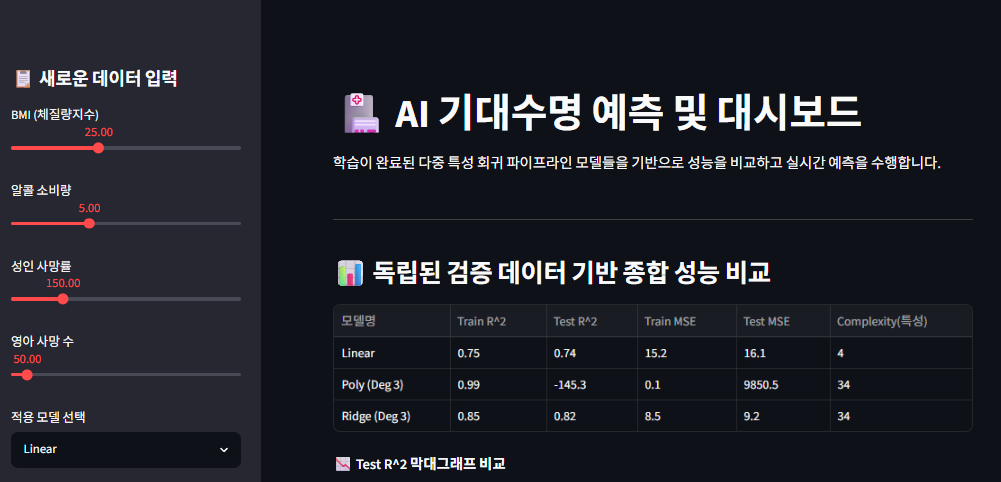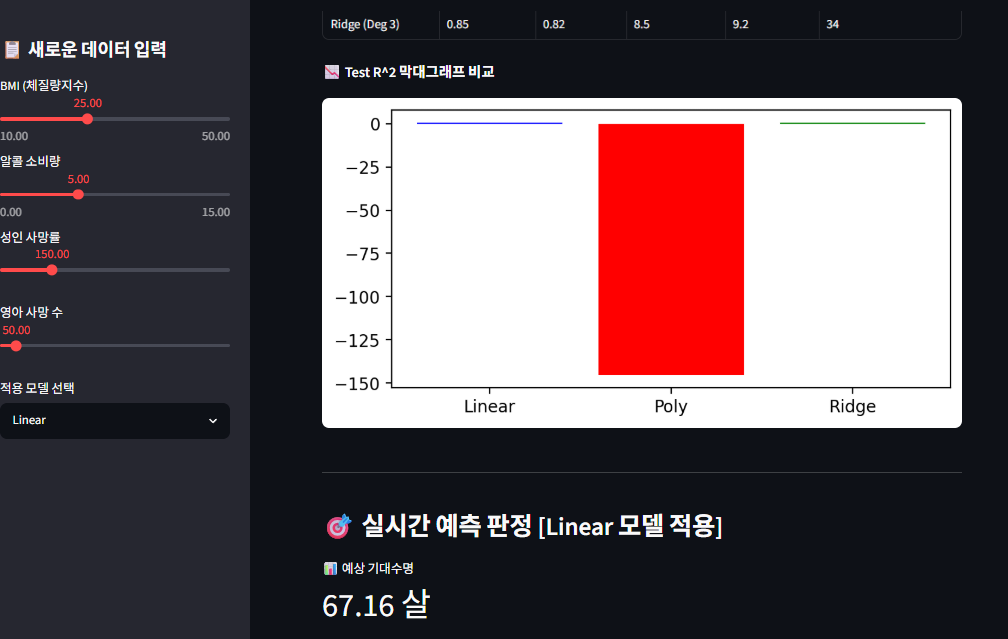